# Quantum-Kernel Clustering, End to End
### A standalone companion to Session 1 — *Quantum Unsupervised Learning (Clustering)*, QML-2026 FDP

This notebook builds a complete quantum-machine-learning clustering pipeline from scratch and runs it on an **ordinary laptop — no quantum hardware required.** It is written to be read on its own: every idea is explained in plain language *before* the code that implements it, so a reader who has never touched quantum computing can still follow the whole story.

**The one-line result it demonstrates.** Ordinary k-means, the workhorse clustering method, fails to separate two interleaved crescent shapes. A small **2-qubit quantum kernel**, fed into a standard clustering method, recovers them. The improvement comes entirely from a *better way of measuring how alike two data points are* — not from any speed-up and not from special hardware.

**How to run it.** `pip install pennylane scikit-learn matplotlib`, then run every cell top to bottom. Everything executes in PennyLane's `default.qubit` simulator on a CPU in well under a minute.

---

## 1. The setting: unsupervised learning and clustering

**Machine learning** comes in two broad flavours. In **supervised learning**, a model is shown examples *with* the right answers attached — pictures labelled "cat" or "dog" — and learns to reproduce those labels. In **unsupervised learning**, there are *no* labels at all; the model is handed a pile of raw data and asked to discover any structure hiding inside it.

**Clustering** is the best-known unsupervised task: sorting data into groups whose members resemble one another, *without being told in advance what the groups are* or even how many there should be. It matters because the vast majority of real-world data — transactions, genomes, sensor readings, telescope images — arrives with no labels, and clustering is usually the very first way anyone makes sense of it.

Every clustering method rests on three choices: a **representation** (each item as a list of numbers, i.e. a point in space), a **similarity** (some rule for how alike two points are), and an **objective** (what makes a grouping "good"). The quantum idea explored here changes only the *middle* one — the notion of similarity — and drops it into machinery that already exists.

## 2. The test problem: two interleaved moons

To make the difference visible, this notebook uses a classic hard case: two crescent ("moon") shapes that curve around each other. The two moons are genuinely separate groups, but they are **not linearly separable** — no straight line cleanly divides them — which is exactly the situation where ordinary k-means struggles.

The code below creates 120 such points and standardises them. The true group of each point (`y`) is generated too, but it is used **only at the very end to score the result** — the clustering algorithms never see it.

> **Term — Standardise:** rescale each feature so it has an average of 0 and a spread of 1, so no single feature dominates the distance calculation just because its numbers happen to be larger.

/Users/sentry/Library/Python/3.9/lib/python/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


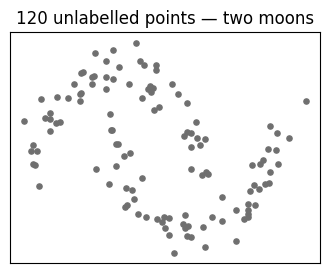

data: (120, 2) -> the model must find the two crescents with NO labels


In [1]:
# Quantum-kernel clustering on two interleaved moons — 2 qubits, laptop CPU
import pennylane as qml
from pennylane import numpy as np
from sklearn.datasets import make_moons
from sklearn.cluster import KMeans, SpectralClustering
from sklearn.metrics import adjusted_rand_score
import matplotlib.pyplot as plt

X, y = make_moons(n_samples=120, noise=0.12, random_state=7)
X = (X - X.mean(0)) / X.std(0)          # standardise; y is kept ONLY to score, never to cluster
plt.figure(figsize=(4, 3))
plt.scatter(X[:, 0], X[:, 1], c="#6f6f6f", s=14)
plt.title("120 unlabelled points — two moons"); plt.xticks([]); plt.yticks([]); plt.show()
print("data:", X.shape, "-> the model must find the two crescents with NO labels")

The plot above is what the algorithm actually receives: a grey cloud with **no colours, no labels** — just positions. A human eye can guess there are two arcs; the task is to get an algorithm to find them using a similarity rule alone.

> **Term — Adjusted Rand Index (ARI):** the score used later to grade the result. It compares the algorithm's grouping against the true groups and returns roughly **1.0 for a perfect match** and **around 0.0 for random guessing.** It is only ever used to *check* the answer, never to help produce it.

## 3. Why ordinary k-means struggles here

**k-means** is the workhorse. It picks a fixed number of group centres, assigns every point to its nearest centre, moves each centre to the average of its points, and repeats until nothing changes. Its notion of similarity is plain **straight-line (Euclidean) distance.**

That straight-line thinking is exactly the weakness. Because "nearest centre" carves space with straight boundaries, k-means slices *through* the two crescents instead of following their curves. It will be run below as the baseline to beat.

> **Term — Euclidean distance:** ordinary straight-line distance between two points, the length of the ruler laid between them.

## 4. The quantum idea: a feature map and a kernel

The quantum approach keeps the *clustering machinery* but replaces the *similarity rule* with one computed by a quantum circuit.

- A **quantum feature map** is a small circuit that takes a data point and encodes it into the state of a few qubits. It effectively lifts the point into a much larger, richer space where curved structure can become easier to separate.
- A **kernel** is simply a number saying how alike two points are. The **quantum kernel** here is the *overlap* between the two quantum states the feature map produces — a quantity the hardware itself computes through interference. States that end up alike give a number near **1**; unrelated states give a number near **0**.
- The overlap is obtained with a standard trick: apply the feature map for the first point, then apply the *inverse* of the feature map for the second point, and read the probability that all qubits return to 0. That probability *is* the squared overlap.

The circuit below uses just **2 qubits** and rotation gates (`RY`) whose angles are set by the data — a lightweight, near-term-friendly recipe.

> **Term — Qubit:** the quantum version of a bit; instead of being only 0 or 1 it can hold a blend of both at once until measured.
>
> **Term — Feature map:** a circuit that turns a classical data point into a quantum state, placing it in a larger space where patterns can be easier to separate.
>
> **Term — Quantum kernel:** a similarity score between two points computed by a quantum circuit as the overlap of their states, richer than plain straight-line distance.

In [2]:
n_qubits = 2
dev = qml.device("default.qubit", wires=n_qubits)

def feature_map(x, scale=0.7):
    "Angle-encode the 2-D point into a 2-qubit state (2 layers)."
    for _ in range(2):
        qml.RY(scale * x[0], wires=0)
        qml.RY(scale * x[1], wires=1)
        qml.CNOT(wires=[0, 1])
        qml.RY(scale * x[1], wires=0)
        qml.RY(scale * x[0], wires=1)
        qml.CNOT(wires=[0, 1])

@qml.qnode(dev)
def overlap(x1, x2):
    feature_map(x1)
    qml.adjoint(feature_map)(x2)      # apply U(x1), then the inverse U(x2)^dagger
    return qml.probs(wires=range(n_qubits))

def kernel(x1, x2):
    return overlap(x1, x2)[0]         # probability of the all-zeros outcome = |<phi(x1)|phi(x2)>|^2

print("k(x0, x0) =", round(float(kernel(X[0], X[0])), 3), "(a point with itself -> 1.0)")
print("k(x0, x5) =", round(float(kernel(X[0], X[5])), 3),
      " k(x0, x60) =", round(float(kernel(X[0], X[60])), 3), "(two other pairs)")

k(x0, x0) = 1.0 (a point with itself -> 1.0)
k(x0, x5) = 0.108  k(x0, x60) = 0.212 (two other pairs)


A point compared with **itself scores exactly 1.0**, as it must — a state overlaps perfectly with itself. Two different points score somewhere between 0 and 1 depending on how alike the circuit considers them. This single function is the whole quantum ingredient; everything else is ordinary data handling.

## 5. Building the kernel (Gram) matrix

To cluster the whole dataset, the kernel is evaluated for **every pair of points**, filling an *n × n* table called the **Gram matrix** `K`, where `K[i, j]` is the similarity between point *i* and point *j*. The heatmap makes its structure visible: bright blocks mean groups of points the quantum kernel considers strongly alike.

> **Term — Gram matrix:** the full table of pairwise similarities for a dataset; every entry is the kernel value for one pair of points.

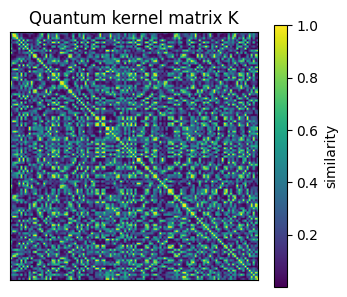

K shape: (120, 120) -> a physically-computed similarity for every pair of points


In [3]:
# Build the full quantum kernel (Gram) matrix K[i,j] = |<phi(xi)|phi(xj)>|^2
K = np.array([[kernel(a, b) for b in X] for a in X])
plt.figure(figsize=(4, 3.4))
plt.imshow(K, cmap="viridis"); plt.colorbar(label="similarity")
plt.title("Quantum kernel matrix K"); plt.xticks([]); plt.yticks([]); plt.show()
print("K shape:", K.shape, "-> a physically-computed similarity for every pair of points")

## 6. Clustering: k-means vs the quantum kernel

Now the two methods are compared on identical data.

- **Classical k-means** clusters using straight-line distance, as described above.
- **Quantum-kernel spectral clustering** feeds the quantum kernel into **spectral clustering**, a standard method that treats the data as a graph and cuts it into pieces using the mathematics of that graph. One practical step first: for each point only its **14 most-similar neighbours** are kept, turning the dense kernel into a *local* graph — spectral clustering works best when connections are local, so that curved shapes stay connected along their length.

The score for each is the Adjusted Rand Index against the true moons.

> **Term — Spectral clustering:** a method that builds a graph linking similar points and splits it into groups using the graph's structure; unlike k-means it can follow curved, non-round shapes.

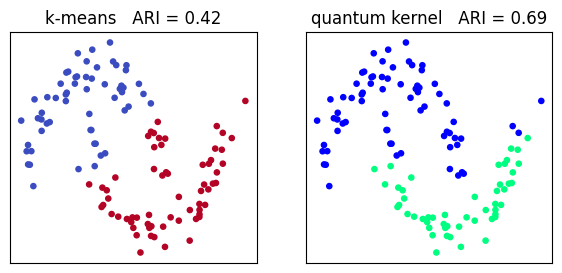

classical k-means ARI        = 0.42   (cuts through the crescents)
quantum-kernel spectral ARI  = 0.69   (recovers the two moons)


In [4]:
# Spectral clustering wants a LOCAL graph, so from the quantum kernel keep
# each point's 14 most-similar neighbours, then symmetrise the matrix.
import numpy as onp
def knn_graph(K, k=14):
    A = onp.zeros_like(K)
    for i in range(len(K)):
        for j in onp.argsort(-K[i])[:k + 1]:
            A[i, j] = K[i, j]
    return onp.maximum(A, A.T)

affinity = knn_graph(K, k=14)
km = KMeans(n_clusters=2, n_init=10, random_state=0).fit(X)
sp = SpectralClustering(n_clusters=2, affinity="precomputed",
                        assign_labels="discretize", random_state=0).fit(affinity)
ari_k = adjusted_rand_score(y, km.labels_)
ari_q = adjusted_rand_score(y, sp.labels_)

fig, ax = plt.subplots(1, 2, figsize=(7, 3))
ax[0].scatter(X[:, 0], X[:, 1], c=km.labels_, cmap="coolwarm", s=14)
ax[0].set_title(f"k-means   ARI = {ari_k:.2f}")
ax[1].scatter(X[:, 0], X[:, 1], c=sp.labels_, cmap="winter", s=14)
ax[1].set_title(f"quantum kernel   ARI = {ari_q:.2f}")
for a in ax: a.set_xticks([]); a.set_yticks([])
plt.show()
print(f"classical k-means ARI        = {ari_k:.2f}   (cuts through the crescents)")
print(f"quantum-kernel spectral ARI  = {ari_q:.2f}   (recovers the two moons)")

## 7. Reading the result

The left panel shows k-means drawing a roughly straight split and **cutting both crescents in half** — a low ARI. The right panel shows the quantum-kernel method **following the two arcs**, recovering the intended groups and scoring much higher. Same data, same clustering machinery; the only thing that changed was the similarity rule.

The takeaway matches the honest message of the talk: on this problem the quantum kernel provides a **richer, non-straight-line notion of similarity** that separates shapes ordinary distance cannot. It did so with two qubits, on a laptop, in a simulator.

## 8. What this does — and does not — prove

Intellectual honesty is part of the lesson:

- **This is a curated example.** The two-moons geometry was chosen because it favours a richer similarity. On data that already suits k-means, the quantum kernel offers no benefit. A fair comparison always benchmarks against a strong classical baseline.
- **No speed-up is claimed here.** Building the kernel still compares every pair of points. The demonstration is about a *different kind of similarity*, not about running faster.
- **This runs in simulation.** On real near-term hardware, noise and the cost of loading data are genuine obstacles; the shallow, 2-qubit design used here is deliberately chosen to be robust to a little noise.

Where a genuine near-term advantage is most defensible is exactly this role: the quantum circuit acts as a **feature generator**, inventing a similarity that then feeds the ordinary clustering methods people already teach.

## 9. Key terms — quick glossary

- **Unsupervised learning** — finding structure in data that carries no labels.
- **Clustering** — grouping data so members of a group are alike, without being given the groups.
- **k-means** — a fast classical method that splits data into a fixed number of round groups using straight-line distance.
- **Euclidean distance** — ordinary straight-line distance between two points.
- **Qubit** — the quantum version of a bit; can hold a blend of 0 and 1 until measured.
- **Feature map** — a circuit that encodes a data point into a quantum state in a larger space.
- **Quantum kernel** — a similarity score between two points computed by a quantum circuit as the overlap of their states.
- **Gram matrix** — the full table of pairwise kernel values for a dataset.
- **Spectral clustering** — a graph-based clustering method that can follow curved shapes.
- **Adjusted Rand Index (ARI)** — a score comparing a clustering to the truth; ~1.0 is perfect, ~0.0 is random.

## References
- Lloyd, Mohseni, Rebentrost, *Quantum algorithms for supervised and unsupervised machine learning* (2013).
- Havlíček et al., *Supervised learning with quantum-enhanced feature spaces*, Nature (2019).
- Schuld & Killoran, *Quantum machine learning in feature Hilbert spaces*, PRL (2019).
- PennyLane documentation — quantum kernels and the `default.qubit` simulator.

*Companion to Session 1, QML-2026 FDP · runs on any laptop, no quantum hardware.*